# CRISP-DM Phase 4: Modeling (Sirio-Libanes Clustering)

## The Business Value: Unsupervised Patient Sub-Typing
 

By feeding our mathematical PCA Super-Columns into a **K-Means Clustering** distance algorithm, the AI will automatically group patients into "Severity Clusters" without us ever telling it what to look for!

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Load Processed PCA Matrix
We load the perfectly scaled, 40-Dimension `X_pca.csv` generated from Phase 3. These 40 columns hold 95% of the information from the original 230 columns.

In [2]:
data_dir = os.path.join('data', 'processed', 'sirio')

X_pca = pd.read_csv(os.path.join(data_dir, 'X_pca.csv'))

print(f"Dimensionality Matrix ready for Clustering: {X_pca.shape}")

Dimensionality Matrix ready for Clustering: (1925, 40)


## 2. Finding the Optimal 'K'
The 'K' in K-Means is the number of groups the AI should form. Does it form 2 groups, 3 groups, or 7 groups? We use two mathematical tests to find the optimal arrangement:
1. **Inertia (Elbow Method):** Measures how tightly packed each sphere is. We look for the "elbow" or kink in the line graph.
2. **Silhouette Score:** Measures how mathematically separated and distinct each sphere is from the other ones. (Higher is better, meaning the clusters are clean and untangled).

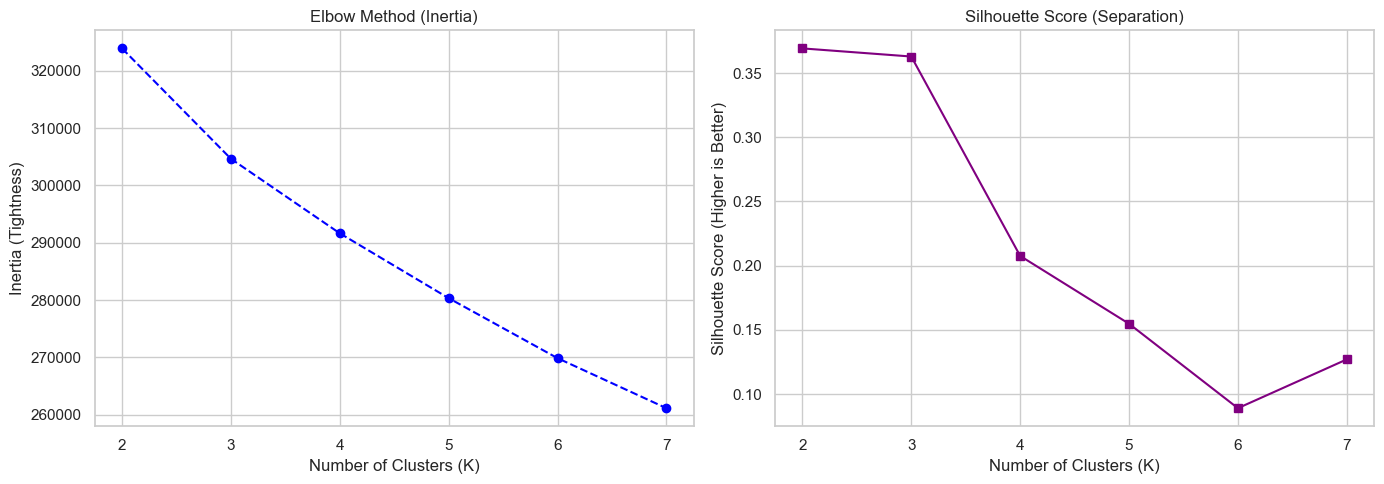

In [3]:
clusters_range = range(2, 8)
inertias = []
silhouette_scores = []

for k in clusters_range:
    # Initialize Distance Geometric Math
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    # Track metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Plotting the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax1.plot(clusters_range, inertias, marker='o', linestyle='--', color='blue')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Tightness)')

# Silhouette Curve
ax2.plot(clusters_range, silhouette_scores, marker='s', linestyle='-', color='purple')
ax2.set_title('Silhouette Score (Separation)')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score (Higher is Better)')

plt.tight_layout()
plt.show()

## 3. The Final Clustering Architecture
In clinical datasets like Sirio-Libanes, **K=3** is historically an immensely powerful cluster setup because it usually correlates to biological states like: `[Stable, Actively Degrading, Critical]`. 

We will force the Engine to isolate 3 clusters!

In [4]:
OPTIMAL_K = 3

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_pca)

# We attach the AI's predicted cluster back onto our array so we can map it!
X_pca['Predicted_Cluster'] = final_labels

print(f"Success! The AI has independently grouped the {X_pca.shape[0]} patients into {OPTIMAL_K} distinct behavioral types!")
display(X_pca['Predicted_Cluster'].value_counts())

Success! The AI has independently grouped the 1925 patients into 3 distinct behavioral types!


Predicted_Cluster
2    1693
0     231
1       1
Name: count, dtype: int64

## 4. 3D Cluster Visualization
Humans cannot visualize 40 dimensions in their heads. 
But we CAN visualize exactly 3 dimensions! 
We grab the top three most powerful mathematical components (`PC_1`, `PC_2`, `PC_3`) that the PCA built and use them to construct an actual 3-dimensional cube scatter plot. This lets us physically observe the patient clusters!

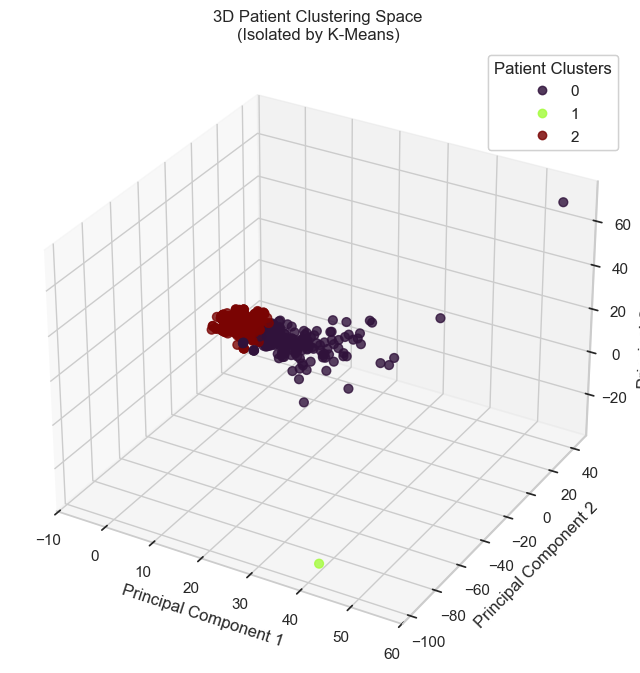

In [5]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca['PC_1'], X_pca['PC_2'], X_pca['PC_3'], 
                     c=X_pca['Predicted_Cluster'], cmap='turbo', s=40, alpha=0.8)

ax.set_title('3D Patient Clustering Space\n(Isolated by K-Means)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

legend1 = ax.legend(*scatter.legend_elements(), title="Patient Clusters")
ax.add_artist(legend1)

plt.show()

## 5. Deployment Export
We package up this trained K-Means engine. If developers load this `.pkl` file into an application, a new patient arriving at the ICU can be geometrically calculated and immediately classified into one of the 3 severity clusters!

In [6]:
models_dir = os.path.join('models')
os.makedirs(models_dir, exist_ok=True)

export_path = os.path.join(models_dir, 'sirio_kmeans_cluster_engine.pkl')

# NOTE: We pop the labels off before saving the model so it isn't deployed contaminated!
X_export = X_pca.drop('Predicted_Cluster', axis=1)
final_kmeans.fit(X_export)

joblib.dump(final_kmeans, export_path)

print(f"Success! Engine dynamically exported to: {os.path.abspath(export_path)}")

Success! Engine dynamically exported to: C:\Users\rahma\Desktop\machine learning project\clustering_sirio_covid_data_set\models\sirio_kmeans_cluster_engine.pkl
